In [21]:
# E-commerce Dataset

## Dataset Understanding

## Data Cleaning

## Exploratory Data Analysis

## Visualizations

## Insights


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
import os
print(os.getlogin())

HP-PC


In [24]:
ecommerce = pd.read_csv(r"C:\Users\HP-PC\Desktop\internship\E-commerce.csv", encoding="latin1")

In [25]:
ecommerce.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-10 08:26,3.39,17850.0,United Kingdom


In [26]:
ecommerce.shape

(541909, 8)

In [27]:
ecommerce.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [28]:
ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [29]:
ecommerce.select_dtypes(include=['int64','float64']).columns

Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')

In [30]:
ecommerce.select_dtypes(include=['object']).columns

Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')

In [32]:
# InvoiceNo
# CustomerID

In [33]:
# This dataset contains online retail transactions including invoice numbers, Stock Code, Description, quantity, Invoice Date, unit price, customer id and country.

In [34]:
ecommerce.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [36]:

ecommerce = ecommerce.fillna({
    'Description': 'Unknown Item',
    'CustomerID': 0               
})



In [37]:

ecommerce.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [38]:
# Data Cleansing Methodology: E-commerce Dataset
# For the E-commerce dataset, missing values in the Description (1,454 rows) and CustomerID (135,080 rows) columns were resolved using a dictionary-based imputation strategy to protect transactional integrity.

# Revenue Retention: Listwise deletion was rejected because dropping over 135,000 rows would erase millions in valid sales revenue. The missing rows still contain critical financial data metrics such as Quantity and UnitPrice.

# Data Type Homogeneity: * Description: Imputed with the text string "Unknown Item" to match its native textual format.

# CustomerID: Imputed with the integer 0. Because customer IDs are strictly numerical, using a text word would break down-stream mathematical operations.

# Operational Classification: Assigning the numeric constant 0 to missing user IDs follows industry-standard retail protocols to isolate "Guest Checkouts" from registered loyalty accounts without losing their corresponding sales impact.

In [48]:

duplicates_count = ecommerce.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")


ecommerce = ecommerce.drop_duplicates()


print(f"Duplicates remaining: {ecommerce.duplicated().sum()}")

Number of duplicate rows found: 0
Duplicates remaining: 0


In [50]:


ecommerce = pd.read_csv(r"C:\Users\HP-PC\Desktop\internship\E-commerce.csv", encoding="latin1")


rows_before = ecommerce.shape[0]


duplicate_count = ecommerce.duplicated().sum()


ecommerce = ecommerce.drop_duplicates()


rows_after = ecommerce.shape[0]


print("=== DUPLICATE REMOVAL REPORT ===")
print(f"Number of duplicates found: {duplicate_count}")
print(f"Rows before cleaning:       {rows_before}")
print(f"Rows after cleaning:        {rows_after}")
print(f"Total duplicates removed:   {rows_before - rows_after}")

=== DUPLICATE REMOVAL REPORT ===
Number of duplicates found: 5268
Rows before cleaning:       541909
Rows after cleaning:        536641
Total duplicates removed:   5268


In [52]:
import pandas as pd

ecommerce = pd.read_csv(
    r"C:\Users\HP-PC\Desktop\internship\E-commerce.csv", encoding="latin1"
)

ecommerce.columns = (
    ecommerce.columns.str.strip().str.lower().str.replace(" ", "_")
)

ecommerce["description"] = ecommerce["description"].str.strip().str.upper()
ecommerce["country"] = ecommerce["country"].str.strip().str.title()

ecommerce["invoicedate"] = pd.to_datetime(
    ecommerce["invoicedate"], format="mixed", errors="coerce"
)

ecommerce["customerid"] = ecommerce["customerid"].fillna(0).astype(int)
ecommerce["description"] = ecommerce["description"].fillna("UNKNOWN ITEM")

negative_quantity_count = (ecommerce["quantity"] < 0).sum()
negative_price_count = (ecommerce["unitprice"] < 0).sum()

qty_mean, qty_std = ecommerce["quantity"].mean(), ecommerce["quantity"].std()
qty_outlier_boundary = qty_mean + (3 * qty_std)
quantity_outliers = (ecommerce["quantity"] > qty_outlier_boundary).sum()

ecommerce = ecommerce.drop_duplicates()

print("E-commerce data processing complete.")
print(f"Flagged: {negative_quantity_count} cancellations/returns.")
print(f"Flagged: {quantity_outliers} statistical quantity outliers.")

E-commerce data processing complete.
Flagged: 10624 cancellations/returns.
Flagged: 256 statistical quantity outliers.


In [54]:
import pandas as pd

ecommerce["revenue"] = ecommerce["quantity"] * ecommerce["unitprice"]

ecommerce_numerical = ecommerce[["quantity", "unitprice", "revenue"]]
ecommerce_summary = pd.DataFrame(
    {
        "Mean": ecommerce_numerical.mean(),
        "Median": ecommerce_numerical.median(),
        "Minimum": ecommerce_numerical.min(),
        "Maximum": ecommerce_numerical.max(),
        "Standard Deviation": ecommerce_numerical.std(),
    }
).T

print("=== E-COMMERCE NUMERICAL SUMMARY METRICS ===")
print(ecommerce_summary)

# FIXED: Added .copy() here to make sales_data a completely independent table
sales_data = ecommerce[ecommerce["quantity"] > 0].copy()

top_selling_products = (
    sales_data.groupby("description")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\n1. TOP 10 SELLING PRODUCTS BY QUANTITY:")
print(top_selling_products)

top_revenue_countries = (
    sales_data.groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\n2. TOP 10 REVENUE GENERATING COUNTRIES:")
print(top_revenue_countries)


sales_data["year_month"] = sales_data["invoicedate"].dt.to_period("M")
monthly_sales = sales_data.groupby("year_month")["revenue"].sum()
print("\n3. MONTHLY SALES TRENDS (REVENUE):")
print(monthly_sales)

most_purchased = sales_data["description"].value_counts().head(10)
print("\n4. TOP 10 MOST FREQUENTLY PURCHASED PRODUCTS (TRANSACTION COUNT):")
print(most_purchased)

top_customers = (
    sales_data[sales_data["customerid"] != 0]
    .groupby("customerid")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\n5. TOP 10 CUSTOMERS BY TOTAL SPEND:")
print(top_customers)

=== E-COMMERCE NUMERICAL SUMMARY METRICS ===
                        quantity     unitprice        revenue
Mean                    9.620029      4.632656      18.123861
Median                  3.000000      2.080000       9.870000
Minimum            -80995.000000 -11062.060000 -168469.600000
Maximum             80995.000000  38970.000000  168469.600000
Standard Deviation    219.130156     97.233118     380.656263

1. TOP 10 SELLING PRODUCTS BY QUANTITY:
description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48375
WHITE HANGING HEART T-LIGHT HOLDER    37876
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
UNKNOWN ITEM                          32547
RABBIT NIGHT LIGHT                    30739
Name: quantity, dtype: int64

2. TOP 10 REVENUE GENERATING COUNTRIES:
country
United Kingd

In [55]:
ecommerce.to_csv(
    r"C:\Users\HP-PC\Desktop\internship\cleaned_ecommerce_sales.csv",
    index=False,
)

with pd.ExcelWriter(
    r"C:\Users\HP-PC\Desktop\internship\ecommerce_summary_statistics.xlsx"
) as writer:
    ecommerce_summary.to_excel(writer, sheet_name="Ecommerce_Summary")

print("E-commerce data and statistical results successfully saved!")

E-commerce data and statistical results successfully saved!


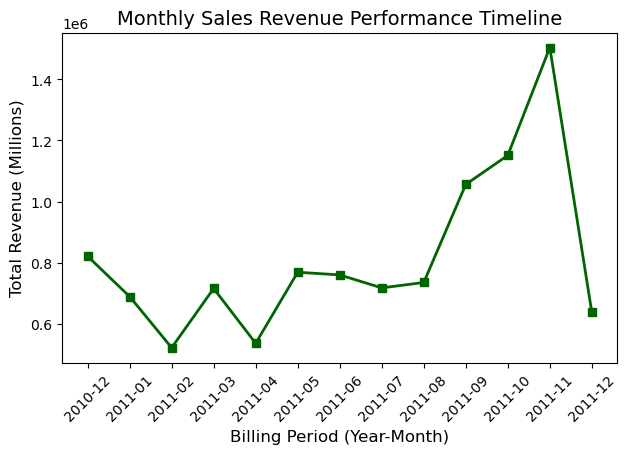

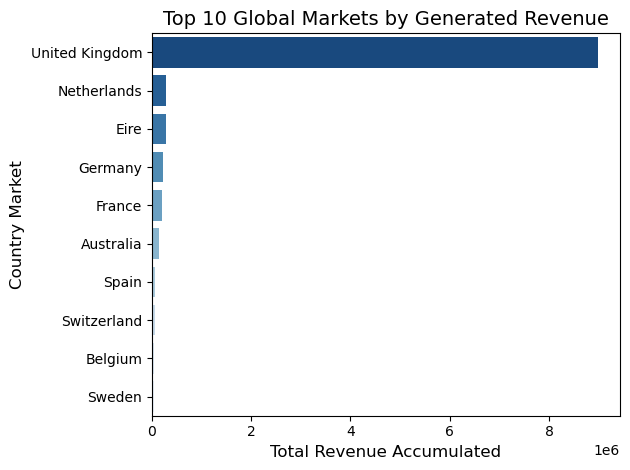

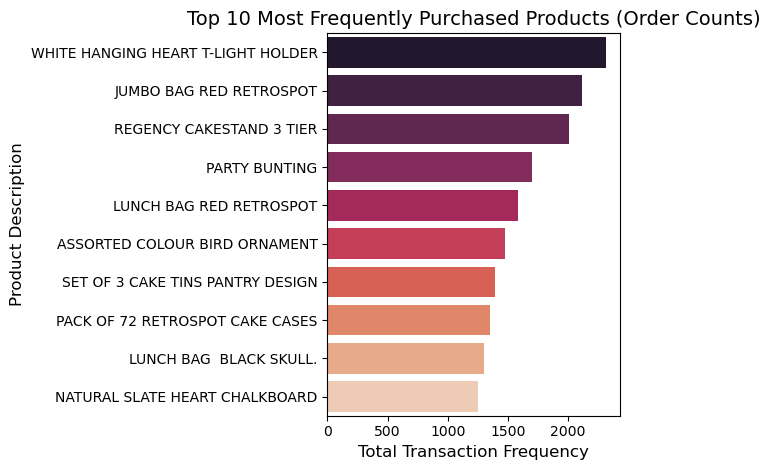

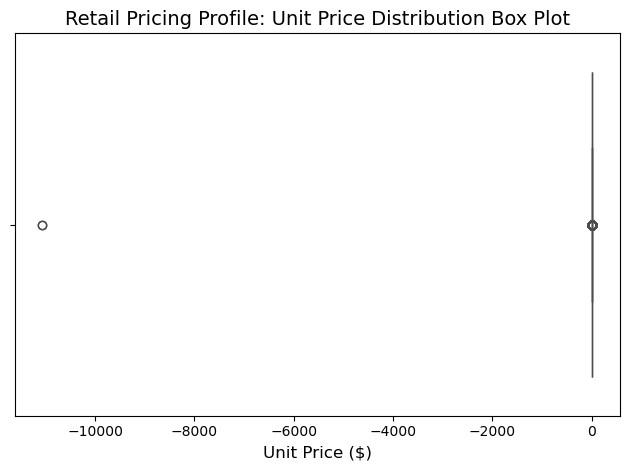

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plot_sales_data = sales_data.copy()
plot_sales_data["year_month_str"] = (
    plot_sales_data["year_month"].astype(str)
)


plt.figure()
monthly_rev = (
    plot_sales_data.groupby("year_month_str")["revenue"].sum().sort_index()
)
plt.plot(
    monthly_rev.index,
    monthly_rev.values,
    marker="s",
    color="darkgreen",
    linewidth=2,
)
plt.title("Monthly Sales Revenue Performance Timeline", fontsize=14)
plt.xlabel("Billing Period (Year-Month)", fontsize=12)
plt.ylabel("Total Revenue (Millions)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("ecommerce_1_monthly_revenue.png")
plt.show()


plt.figure()
top_rev_countries = (
    plot_sales_data.groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
sns.barplot(
    x=top_rev_countries.values,
    y=top_rev_countries.index,
    hue=top_rev_countries.index,
    palette="Blues_r",
    legend=False,
)
plt.title("Top 10 Global Markets by Generated Revenue", fontsize=14)
plt.xlabel("Total Revenue Accumulated", fontsize=12)
plt.ylabel("Country Market", fontsize=12)
plt.tight_layout()
plt.savefig("ecommerce_2_top_countries_revenue.png")
plt.show()


plt.figure()
top_freq_prod = plot_sales_data["description"].value_counts().head(10)
sns.barplot(
    x=top_freq_prod.values,
    y=top_freq_prod.index,
    hue=top_freq_prod.index,
    palette="rocket",
    legend=False,
)
plt.title("Top 10 Most Frequently Purchased Products (Order Counts)", fontsize=14)
plt.xlabel("Total Transaction Frequency", fontsize=12)
plt.ylabel("Product Description", fontsize=12)
plt.tight_layout()
plt.savefig("ecommerce_3_frequent_products.png")
plt.show()


plt.figure()
sns.boxplot(
    data=plot_sales_data[plot_sales_data["unitprice"] < 20],
    x="unitprice",
    color="orange",
)
plt.title("Retail Pricing Profile: Unit Price Distribution Box Plot", fontsize=14)
plt.xlabel("Unit Price ($)", fontsize=12)
plt.tight_layout()
plt.savefig("ecommerce_4_price_boxplot.png")
plt.show()


plt.figure()
# Filter for typical transaction sizes (< $1000) to see distribution shape clearly
sns.histplot(
    data=plot_sales_data[plot_sales_data["revenue"] < 1000],
    x="revenue",
    bins=50,
    color="teal",
    kde=True,
)
plt.title("Transaction Value Spectrum (Orders under $1,000)", fontsize=14)
plt.xlabel("Calculated Order Line Value ($)", fontsize=12)
plt.ylabel("Frequency Number", fontsize=12)
plt.tight_layout()
plt.savefig("ecommerce_5_revenue_histogram.png")
plt.show()